# 📈 Oráculo Financiero AI

**Predicción direccional del mercado de valores mediante Machine Learning.**

👤 **Autores:** Enrique Sucre y Leandro Roldan  
🎓  Proyecto Final - 4Geeks Academy

## 📑 Índice
1. [El Problema](#-El-problema)
2. [Los Datos](#-los-datos)
3. [Análisis Exploratorio (EDA)](#-analisis-exploratorio-EDA)
4. [El Combate de Modelos](#-el-combate-de-modelos)
5. [Optimización y Resultados](#-optimizacion-y-resultados)

# El Problema
Los mercados financieros son altamente volátiles y están llenos de "ruido". Nuestro objetivo en este proyecto fue construir una herramienta probabilística de apoyo para *traders*. Buscamos responder a la pregunta: **¿Puede un algoritmo de Inteligencia Artificial aprender a leer indicadores técnicos (como el RSI o el MACD) para predecir si el cierre de mañana será positivo 🟢 o negativo 🔴?**

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import datetime
import requests

pd.set_option('display.max_columns', None)
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


# Los Datos
Trabajamos con un set de datos históricos que incluye las cotizaciones diarias y el volumen de múltiples empresas de Wall Street.

In [2]:
def obtener_tickers_sp500():
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    try:
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
        }
        response = requests.get(url, headers=headers)
        response.raise_for_status()
        tables = pd.read_html(response.text)
        df_wiki = tables[0]
        tickers = df_wiki['Symbol'].str.replace('.', '-', regex=False).tolist()
        return tickers
    except Exception as e:
        print(f"Error al obtener tickers: {e}")
        return []

def calcular_35_indicadores(df):
    data = df.copy()

    # --- GRUPO 1: DATOS BASICOS

    # --- GRUPO 2: TENDENCIA Y MEDIAS MOVILES -
    data['SMA_10']  = data['Adj Close'].rolling(window=10).mean()
    data['SMA_50']  = data['Adj Close'].rolling(window=50).mean()
    data['SMA_200'] = data['Adj Close'].rolling(window=200).mean()
    data['EMA_12']  = data['Adj Close'].ewm(span=12, adjust=False).mean()
    data['EMA_26']  = data['Adj Close'].ewm(span=26, adjust=False).mean()

    # --- GRUPO 3: VOLATILIDAD -
    data['Std_20'] = data['Adj Close'].rolling(window=20).std()
    data['Bollinger_Upper'] = data['SMA_50'] + (data['Std_20'] * 2) # Usando SMA local o 20
    data['Bollinger_Lower'] = data['SMA_50'] - (data['Std_20'] * 2)
    data['Daily_Range'] = data['High'] - data['Low']
    data['Range_Pct'] = (data['Daily_Range'] / data['Open']) * 100

    # --- GRUPO 4: RETORNOS -
    data['Daily_Return'] = data['Adj Close'].pct_change()
    data['Log_Return'] = np.log(data['Adj Close'] / data['Adj Close'].shift(1))
    data['Cumulative_Return'] = (1 + data['Daily_Return']).cumprod()
    data['Is_Positive_Day'] = (data['Close'] > data['Open']).astype(int)

    # --- GRUPO 5: MOMENTUM & MACD -
    data['MACD_Line'] = data['EMA_12'] - data['EMA_26']
    data['MACD_Signal'] = data['MACD_Line'].ewm(span=9, adjust=False).mean()
    data['MACD_Hist'] = data['MACD_Line'] - data['MACD_Signal']

    # RSI (Relative Strength Index)
    delta = data['Adj Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    data['RSI_14'] = 100 - (100 / (1 + rs))
    data['Momentum_10'] = data['Adj Close'] - data['Adj Close'].shift(10)

    # --- GRUPO 6: VOLUMEN RELATIVO -
    data['Vol_SMA_20'] = data['Volume'].rolling(window=20).mean()
    data['Vol_Ratio'] = data['Volume'] / data['Vol_SMA_20']
    data['Vol_Change'] = data['Volume'].pct_change()

    # --- GRUPO 7: ESTADÍSTICOS Y SPREADS -
    data['High_Low_Spread'] = (data['High'] - data['Low']) / data['Low']
    data['Close_Open_Spread'] = (data['Close'] - data['Open']) / data['Open']
    data['Typical_Price'] = (data['High'] + data['Low'] + data['Close']) / 3
    data['Z_Score_20'] = (data['Adj Close'] - data['Adj Close'].rolling(20).mean()) / data['Std_20']
    data['Above_SMA200'] = (data['Adj Close'] > data['SMA_200']).astype(int)


    data['Pct_From_High_50'] = (data['Adj Close'] / data['Adj Close'].rolling(50).max()) - 1

    return data


### Descarga de datos (S&P 500)
#### Descarga de data másiva

In [3]:
import os
import pandas as pd
import yfinance as yf
import datetime
from sqlalchemy import create_engine, inspect

# --- CONFIGURACIÓN ---
db_name = 'sp500_market_data.db'
table_name = 'sp500_daily_metrics'
engine = create_engine(f'sqlite:///{db_name}')

# Bandera de control
data_found = False

# 1. VERIFICACIÓN: ¿Existen los datos en SQL?
if os.path.exists(db_name):
    inspector = inspect(engine)
    if table_name in inspector.get_table_names():
        print(f"✅ Base de datos encontrada: {db_name}")
        print(f"   -> Cargando datos desde SQL (omitir descarga)...")

        # Carga rápida a memoria desde el archivo local
        final_df = pd.read_sql(f"SELECT * FROM {table_name}", con=engine)

        data_found = True
        print(f"   -> Carga completada. Filas: {len(final_df):,} | Columnas: {len(final_df.columns)}")

# 2. ACCIÓN: Descargar SOLO si NO se encontraron datos (data_found == False)
if not data_found:
    print(f"⚠️ No se encontraron datos previos. Iniciando proceso de descarga...")

    # A. Obtener Tickers (Asegúrate de tener la función obtener_tickers_sp500 definida previamente)
    tickers = obtener_tickers_sp500()
    print(f"   -> Tickers identificados: {len(tickers)}")

    if len(tickers) == 0:
         raise ValueError("No se pudieron obtener tickers. Revisa la conexión o Wikipedia.")

    # B. Descargar (Últimos 2 años)
    end_date = datetime.datetime.now()
    start_date = end_date - datetime.timedelta(days=730)
    print(f"   -> Descargando desde Yahoo Finance ({start_date.date()} - {end_date.date()})...")

    # Descarga masiva
    raw_data = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=False, threads=True)

    # C. Procesar y Calcular (35 Columnas)
    processed_frames = []
    print(f"   -> Calculando indicadores para cada empresa...")

    for ticker in tickers:
        try:
            # Verificamos si el ticker existe en las columnas descargadas
            if ticker not in raw_data.columns.levels[0]:
                continue

            df_ticker = raw_data[ticker].copy()

            # Filtros de calidad de data
            if df_ticker.empty or len(df_ticker) < 50:
                continue

            # Usamos la función de cálculo definida en celdas anteriores
            df_ticker = calcular_35_indicadores(df_ticker)

            # Añadir columna identificadora
            df_ticker['Ticker'] = ticker

            # Limpiar vacíos iniciales (por las medias móviles)
            df_ticker.dropna(inplace=True)

            processed_frames.append(df_ticker)
        except Exception as e:
            continue

    # Concatenar todos los dataframes
    final_df = pd.concat(processed_frames)

    # Reordenar columnas para que Ticker sea la primera
    cols = ['Ticker'] + [c for c in final_df.columns if c != 'Ticker']
    final_df = final_df[cols]

    # D. Guardar en SQL para el futuro
    print(f"   -> Guardando en {db_name}...")

    # Reset index para que la fecha (Date) se guarde como columna explícita
    if 'Date' not in final_df.columns:
        final_df_sql = final_df.reset_index()
    else:
        final_df_sql = final_df.copy()

    final_df_sql.to_sql(name=table_name, con=engine, if_exists='replace', index=False, chunksize=1000)
    print(f"🚀 Proceso finalizado. Datos guardados exitosamente en SQL.")


⚠️ No se encontraron datos previos. Iniciando proceso de descarga...


C:\Users\rolda\AppData\Local\Temp\ipykernel_10792\407439182.py:9: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


   -> Tickers identificados: 503
   -> Descargando desde Yahoo Finance (2024-03-20 - 2026-03-20)...


[*********************100%***********************]  503 of 503 completed

4 Failed downloads:
['ROP', 'DG', 'KLAC', 'FOX']: TypeError("'NoneType' object is not subscriptable")


   -> Calculando indicadores para cada empresa...


C:\Users\rolda\AppData\Local\Temp\ipykernel_10792\407439182.py:37: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Daily_Return'] = data['Adj Close'].pct_change()
C:\Users\rolda\AppData\Local\Temp\ipykernel_10792\407439182.py:58: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Vol_Change'] = data['Volume'].pct_change()
C:\Users\rolda\AppData\Local\Temp\ipykernel_10792\407439182.py:37: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill

   -> Guardando en sp500_market_data.db...
🚀 Proceso finalizado. Datos guardados exitosamente en SQL.


#### Guardamos toda la data en una tabla de SQL

In [4]:
import os
import pandas as pd
from sqlalchemy import create_engine

db_name = 'sp500_market_data.db'
table_name = 'sp500_daily_metrics'

# Verificamos si el archivo ya existe en el sistema
if os.path.exists(db_name):
    print(f"✅ La base de datos '{db_name}' YA EXISTE.")
    print("No se ha realizado ninguna operación de escritura nueva.")

    engine = create_engine(f'sqlite:///{db_name}')
    try:
        # Hacemos una consulta rápida para confirmar
        with engine.connect() as conn:
            # Esta línea verifica si la tabla existe sin leer toda la data
            check = pd.read_sql(f"SELECT COUNT(*) FROM {table_name}", conn)
        print(f"   -> Conexión exitosa. La tabla '{table_name}' contiene datos.")
    except Exception as e:
        print(f"   -> El archivo existe pero hubo un error al leer: {e}")

else:
    print(f"⚠️ La base de datos '{db_name}' NO existe. Iniciando guardado...")

    # Crear el motor
    engine = create_engine(f'sqlite:///{db_name}')

    # Preparar el DataFrame (reset index para guardar la fecha)
    if 'Date' not in final_df.columns:
        final_df_sql = final_df.reset_index()
    else:
        final_df_sql = final_df.copy()

    # Guardar en SQL
    final_df_sql.to_sql(
        name=table_name,
        con=engine,
        if_exists='replace',
        index=False,
        chunksize=1000
    )

    print(f"🚀 ¡Éxito! Nueva base de datos creada: {db_name}")

✅ La base de datos 'sp500_market_data.db' YA EXISTE.
No se ha realizado ninguna operación de escritura nueva.
   -> Conexión exitosa. La tabla 'sp500_daily_metrics' contiene datos.


### Verificación de SQL

In [5]:

query = """
SELECT Date, Ticker, "Adj Close", RSI_14
FROM sp500_daily_metrics
WHERE Ticker = 'AAPL'
ORDER BY Date DESC
LIMIT 5
"""

df_verificacion = pd.read_sql(query, con=engine)

print("Consulta de prueba (Apple, últimos 5 registros en BD):")
display(df_verificacion)


print("\nEstructura de la tabla guardada:")
# Usar final_df (siempre definido: cargado desde SQL o creado en descarga)
df_schema = final_df.reset_index() if 'Date' not in final_df.columns else final_df
inspector = pd.io.sql.get_schema(df_schema, table_name)
print(inspector)

Consulta de prueba (Apple, últimos 5 registros en BD):


,Date,Ticker,Adj Close,RSI_14
0,2026-03-20 00:00:00.000000,AAPL,248.720093,24.160271
1,2026-03-19 00:00:00.000000,AAPL,248.960007,25.655808
2,2026-03-18 00:00:00.000000,AAPL,249.940002,20.537773
3,2026-03-17 00:00:00.000000,AAPL,254.229996,22.253049
4,2026-03-16 00:00:00.000000,AAPL,252.820007,23.692823



Estructura de la tabla guardada:
CREATE TABLE "sp500_daily_metrics" (
"Date" TIMESTAMP,
  "Ticker" TEXT,
  "Open" REAL,
  "High" REAL,
  "Low" REAL,
  "Close" REAL,
  "Adj Close" REAL,
  "Volume" REAL,
  "SMA_10" REAL,
  "SMA_50" REAL,
  "SMA_200" REAL,
  "EMA_12" REAL,
  "EMA_26" REAL,
  "Std_20" REAL,
  "Bollinger_Upper" REAL,
  "Bollinger_Lower" REAL,
  "Daily_Range" REAL,
  "Range_Pct" REAL,
  "Daily_Return" REAL,
  "Log_Return" REAL,
  "Cumulative_Return" REAL,
  "Is_Positive_Day" INTEGER,
  "MACD_Line" REAL,
  "MACD_Signal" REAL,
  "MACD_Hist" REAL,
  "RSI_14" REAL,
  "Momentum_10" REAL,
  "Vol_SMA_20" REAL,
  "Vol_Ratio" REAL,
  "Vol_Change" REAL,
  "High_Low_Spread" REAL,
  "Close_Open_Spread" REAL,
  "Typical_Price" REAL,
  "Z_Score_20" REAL,
  "Above_SMA200" INTEGER,
  "Pct_From_High_50" REAL
)


### Prueba

In [6]:
import pandas as pd
from sqlalchemy import create_engine

# 1. Conectar a la base de datos que creamos
# (Asegúrate de que el nombre del archivo .db sea el mismo que usaste antes)
engine = create_engine('sqlite:///sp500_market_data.db')


query = """
SELECT * FROM sp500_daily_metrics
WHERE Ticker = 'AAPL'
ORDER BY Date DESC
LIMIT 5
"""


df_apple_recent = pd.read_sql(query, con=engine)


print("Mostrando los últimos 5 días de Apple:")
display(df_apple_recent)

Mostrando los últimos 5 días de Apple:


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,SMA_10,SMA_50,SMA_200,EMA_12,EMA_26,Std_20,Bollinger_Upper,Bollinger_Lower,Daily_Range,Range_Pct,Daily_Return,Log_Return,Cumulative_Return,Is_Positive_Day,MACD_Line,MACD_Signal,MACD_Hist,RSI_14,Momentum_10,Vol_SMA_20,Vol_Ratio,Vol_Change,High_Low_Spread,Close_Open_Spread,Typical_Price,Z_Score_20,Above_SMA200,Pct_From_High_50
0,2026-03-20 00:00:00.000000,AAPL,248.110001,249.059998,246.610001,248.720093,248.720093,25787808.0,254.207008,261.042478,246.454898,254.533398,258.658842,7.862548,276.767575,245.317381,2.449997,0.987464,-0.000964,-0.000964,1.404733,1,-4.125444,-2.810074,-1.315370,24.160271,-8.739899,38364205.4,0.672184,-0.259465,0.009935,0.002459,248.130030,-1.437754,1,-0.104873
1,2026-03-19 00:00:00.000000,AAPL,249.399994,251.830002,247.300003,248.960007,248.960007,34823200.0,255.080998,261.269809,246.224564,255.590363,259.453942,7.451455,276.172719,246.366898,4.529999,1.816359,-0.003921,-0.003929,1.406088,0,-3.863580,-2.481232,-1.382348,25.655808,-11.330002,39178340.0,0.888838,-0.026140,0.018318,-0.001764,249.363337,-1.591299,1,-0.104009
2,2026-03-18 00:00:00.000000,AAPL,252.630005,254.940002,249.000000,249.940002,249.940002,35757900.0,256.213998,261.532903,245.985204,256.795882,260.293457,6.911716,275.356336,247.709470,5.940002,2.351266,-0.016874,-0.017018,1.411623,0,-3.497575,-2.135645,-1.361930,20.537773,-12.579987,38979445.0,0.917353,0.104948,0.023855,-0.010648,251.293335,-1.657837,1,-0.100482
3,2026-03-17 00:00:00.000000,AAPL,252.960007,255.130005,252.179993,254.229996,254.229996,32361600.0,257.471997,261.874306,245.736707,258.042405,261.121734,6.385413,274.645132,249.103480,2.950012,1.166197,0.005577,0.005562,1.435852,1,-3.079328,-1.795162,-1.284166,22.253049,-9.520004,38901715.0,0.831881,0.008960,0.011698,0.005021,253.846664,-1.235473,1,-0.085043
4,2026-03-16 00:00:00.000000,AAPL,252.110001,253.889999,249.880005,252.820007,252.820007,32074200.0,258.423997,262.204839,245.462274,258.735571,261.673073,6.116867,274.438573,249.971105,4.009995,1.590573,0.010795,0.010737,1.427889,1,-2.937502,-1.474121,-1.463381,23.692823,-11.899994,40207090.0,0.797725,-0.131487,0.016048,0.002816,252.196671,-1.599102,1,-0.090117


In [7]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine('sqlite:///sp500_market_data.db')
table_name = 'sp500_daily_metrics'

query_filas = f"SELECT COUNT(*) FROM {table_name}"
df_count = pd.read_sql(query_filas, con=engine)
total_filas = df_count.iloc[0, 0]

query_cols = f"SELECT * FROM {table_name} LIMIT 1"
df_estructura = pd.read_sql(query_cols, con=engine)
total_columnas = len(df_estructura.columns)

total_datos = total_filas * total_columnas

print(f"Tabla: {table_name}")
print(f"Total de Filas: {total_filas:,.0f}")
print(f"Total de Columnas: {total_columnas:,.0f}")
print(f"Total de Datos: {total_datos:,.0f}")

Tabla: sp500_daily_metrics
Total de Filas: 150,571
Total de Columnas: 36
Total de Datos: 5,420,556


# Analisis Exploratorio EDA

In [8]:
final_df.duplicated().sum()

np.int64(0)

In [9]:
final_df.to_csv('../data/raw/datos_crudos.csv')

In [14]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 150571 entries, 2025-01-03 to 2026-03-20
Data columns (total 35 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Ticker             150571 non-null  object 
 1   Open               150571 non-null  float64
 2   High               150571 non-null  float64
 3   Low                150571 non-null  float64
 4   Close              150571 non-null  float64
 5   Adj Close          150571 non-null  float64
 6   Volume             150571 non-null  float64
 7   SMA_10             150571 non-null  float64
 8   SMA_50             150571 non-null  float64
 9   SMA_200            150571 non-null  float64
 10  EMA_12             150571 non-null  float64
 11  EMA_26             150571 non-null  float64
 12  Std_20             150571 non-null  float64
 13  Bollinger_Upper    150571 non-null  float64
 14  Bollinger_Lower    150571 non-null  float64
 15  Daily_Range        150571 non-null 

In [17]:
# Convertimos el índice en una columna normal
final_df = final_df.reset_index()

# Ahora sí, tu código original debería funcionar:
final_df['Date'] = pd.to_datetime(final_df['Date'])
resumen_tickers = final_df.groupby('Ticker')['Date'].agg(['min', 'max', 'count'])

print("--- Resumen de fechas por acción ---")
print(resumen_tickers)

--- Resumen de fechas por acción ---
              min        max  count
Ticker                             
A      2025-01-03 2026-03-20    303
AAPL   2025-01-03 2026-03-20    303
ABBV   2025-01-03 2026-03-20    303
ABNB   2025-01-03 2026-03-20    303
ABT    2025-01-03 2026-03-20    303
...           ...        ...    ...
XYZ    2025-01-03 2026-03-20    303
YUM    2025-01-03 2026-03-20    303
ZBH    2025-01-03 2026-03-20    303
ZBRA   2025-01-03 2026-03-20    303
ZTS    2025-01-03 2026-03-20    303

[498 rows x 3 columns]


In [18]:
# Filtramos solo la acción 'MMM', ordenamos por fecha y vemos las primeras 5 filas
columnas_clave = ['Date', 'Close', 'SMA_10', 'SMA_50', 'SMA_200']
primeros_dias = final_df[final_df['Ticker'] == 'MMM'].sort_values('Date')[columnas_clave].head(5)

print("\n--- Primeros 5 días de MMM ---")
print(primeros_dias)


--- Primeros 5 días de MMM ---
Price       Date       Close      SMA_10      SMA_50     SMA_200
0     2025-01-03  129.869995  126.522810  126.663451  112.656040
1     2025-01-06  130.289993  126.831569  126.723183  112.858659
2     2025-01-07  132.770004  127.172570  126.859370  113.074357
3     2025-01-08  134.529999  127.714853  127.063384  113.303028
4     2025-01-10  131.210007  127.797906  127.094833  113.523266


### Nuestra variable a predecir sera 'Is_Positive_Day'


C:\Users\rolda\AppData\Local\Temp\ipykernel_10792\222053810.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=final_df, x='Is_Positive_Day', palette='viridis')


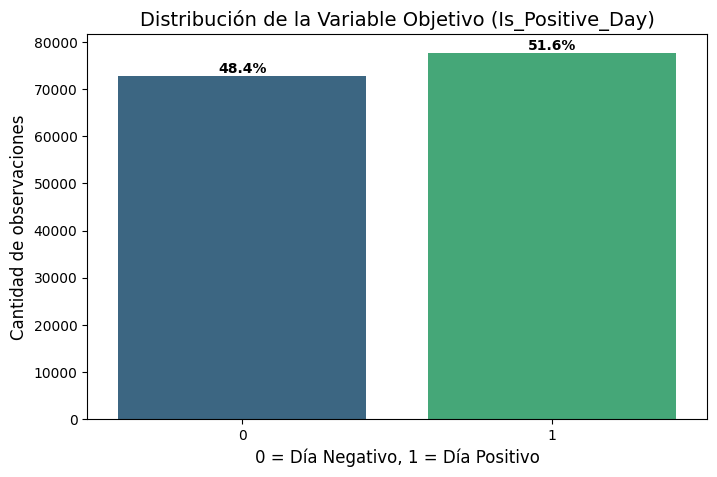

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Gráfico de barras para la variable objetivo
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=final_df, x='Is_Positive_Day', palette='viridis')
plt.title('Distribución de la Variable Objetivo (Is_Positive_Day)', fontsize=14)
plt.xlabel('0 = Día Negativo, 1 = Día Positivo', fontsize=12)
plt.ylabel('Cantidad de observaciones', fontsize=12)

# Añadir los porcentajes encima de las barras
total = len(final_df['Is_Positive_Day'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontweight='bold')

plt.show()

Para ello corroboramos que los datos esten balanceados.

In [20]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150571 entries, 0 to 150570
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Date               150571 non-null  datetime64[ns]
 1   Ticker             150571 non-null  object        
 2   Open               150571 non-null  float64       
 3   High               150571 non-null  float64       
 4   Low                150571 non-null  float64       
 5   Close              150571 non-null  float64       
 6   Adj Close          150571 non-null  float64       
 7   Volume             150571 non-null  float64       
 8   SMA_10             150571 non-null  float64       
 9   SMA_50             150571 non-null  float64       
 10  SMA_200            150571 non-null  float64       
 11  EMA_12             150571 non-null  float64       
 12  EMA_26             150571 non-null  float64       
 13  Std_20             150571 non-null  float64 

## Analsis Univariante


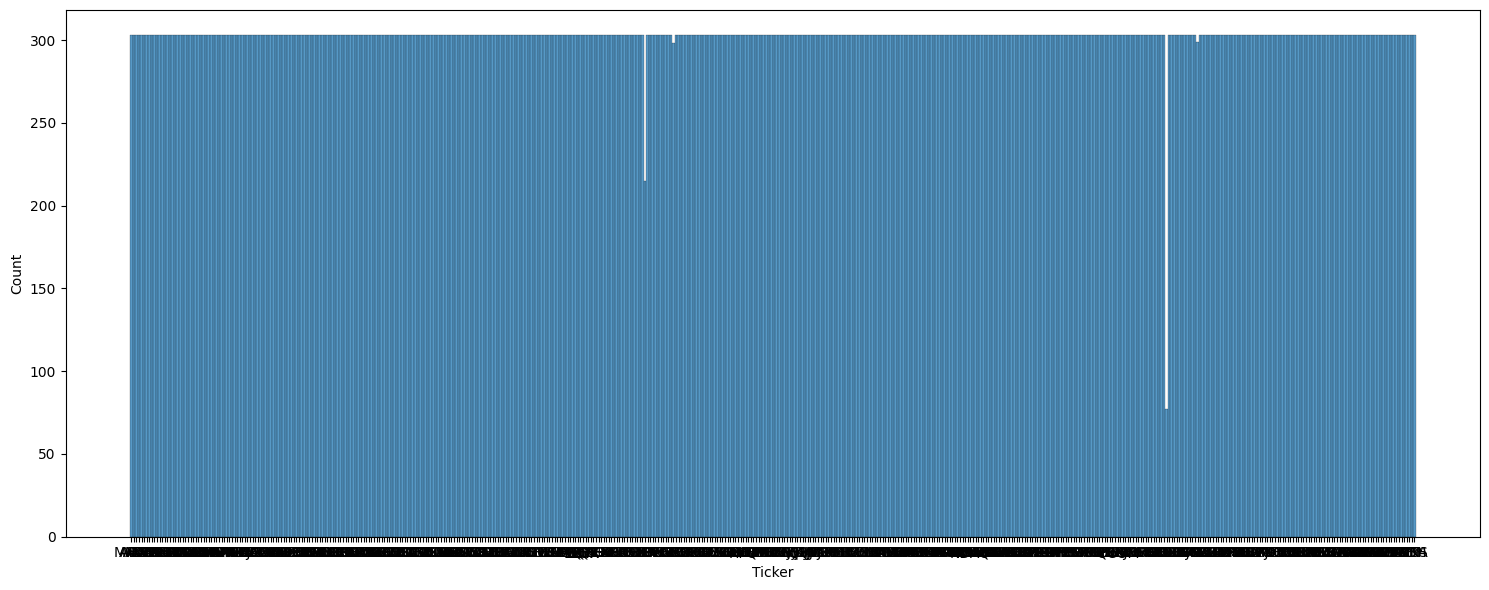

In [21]:
fig, axis= plt.subplots(1, figsize=(15,6))

sns.histplot( data = final_df, x = 'Ticker')
plt.tight_layout()
plt.show()

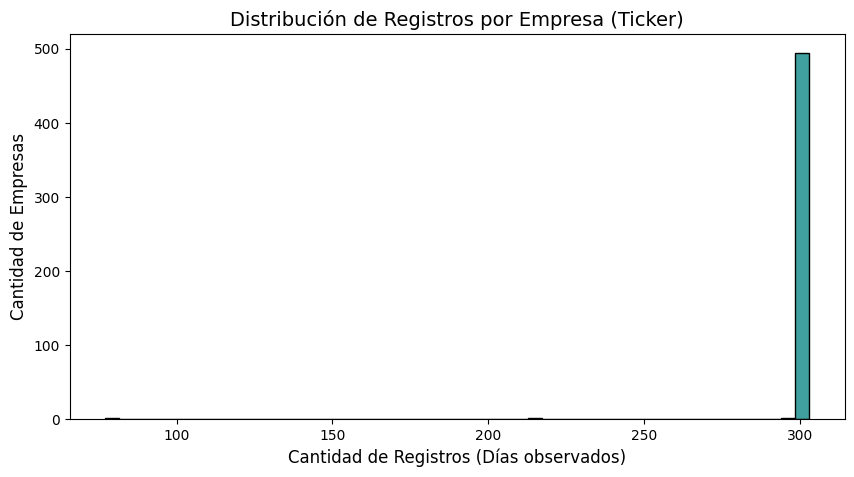

In [22]:
conteo_tickers = final_df['Ticker'].value_counts()

# 2. Graficamos la distribución de esos conteos
plt.figure(figsize=(10, 5))
sns.histplot(conteo_tickers, bins=50, color='teal')
plt.title('Distribución de Registros por Empresa (Ticker)', fontsize=14)
plt.xlabel('Cantidad de Registros (Días observados)', fontsize=12)
plt.ylabel('Cantidad de Empresas', fontsize=12)

plt.show()

In [23]:
# 1. Contamos cuántos registros (filas) tiene cada Ticker
conteo_tickers = final_df['Ticker'].value_counts()

# 2. Obtenemos el número máximo de días registrados (debería ser alrededor de 302)
max_dias = conteo_tickers.max()

# 3. Filtramos solo las empresas que tienen menos días que el máximo
empresas_incompletas = conteo_tickers[conteo_tickers < max_dias]

# 4. Mostramos los resultados
print(f"Días esperados por empresa (historial completo): {max_dias}")
print(f"Total de empresas con historial incompleto: {len(empresas_incompletas)}\n")
print("--- Detalle de empresas incompletas ---")
print(empresas_incompletas.sort_values())

Días esperados por empresa (historial completo): 303
Total de empresas con historial incompleto: 4

--- Detalle de empresas incompletas ---
Ticker
SNDK     77
FISV    215
GEV     298
SOLV    299
Name: count, dtype: int64


En el primer grafico de nuestra variable categorica, podemos ver que hay datos faltantes, que aunque no tengamos nulos en nuestra base de datos, este grafico nos muestra que probablemente hayan acciones que no hayan estado cotizando los dos años completos en nuestro periodo de muestra. En este caso son las acciones con el Ticker de SNDK, FISV, GEV y SOLV son las que tienen datos faltantes.

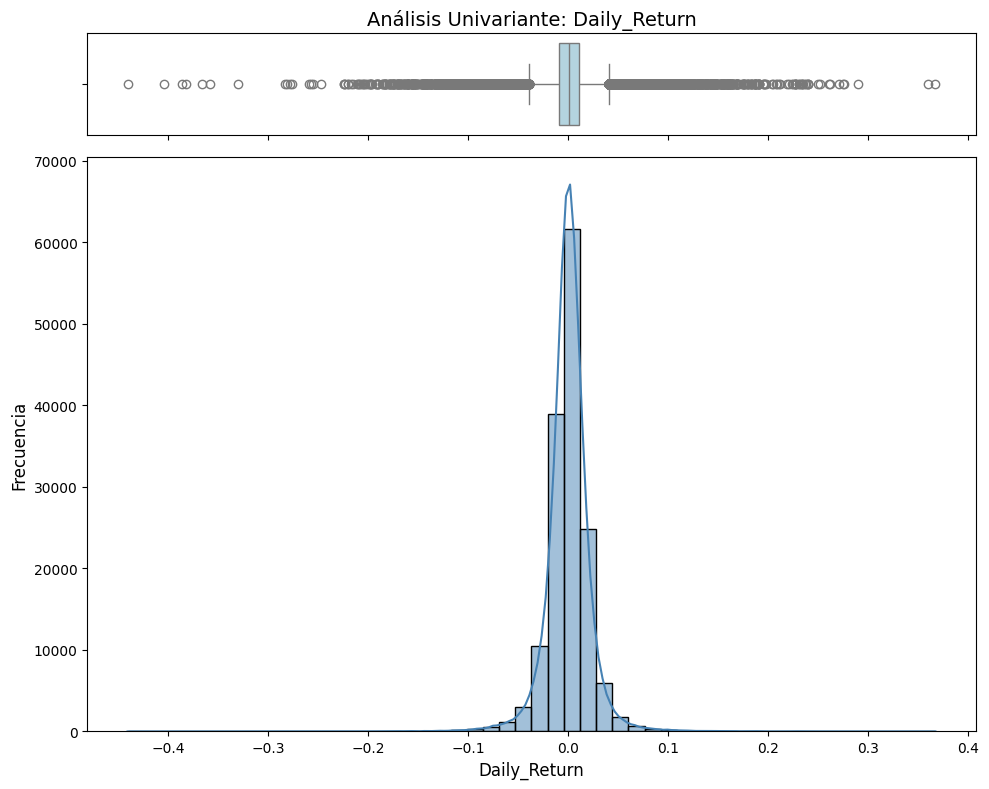

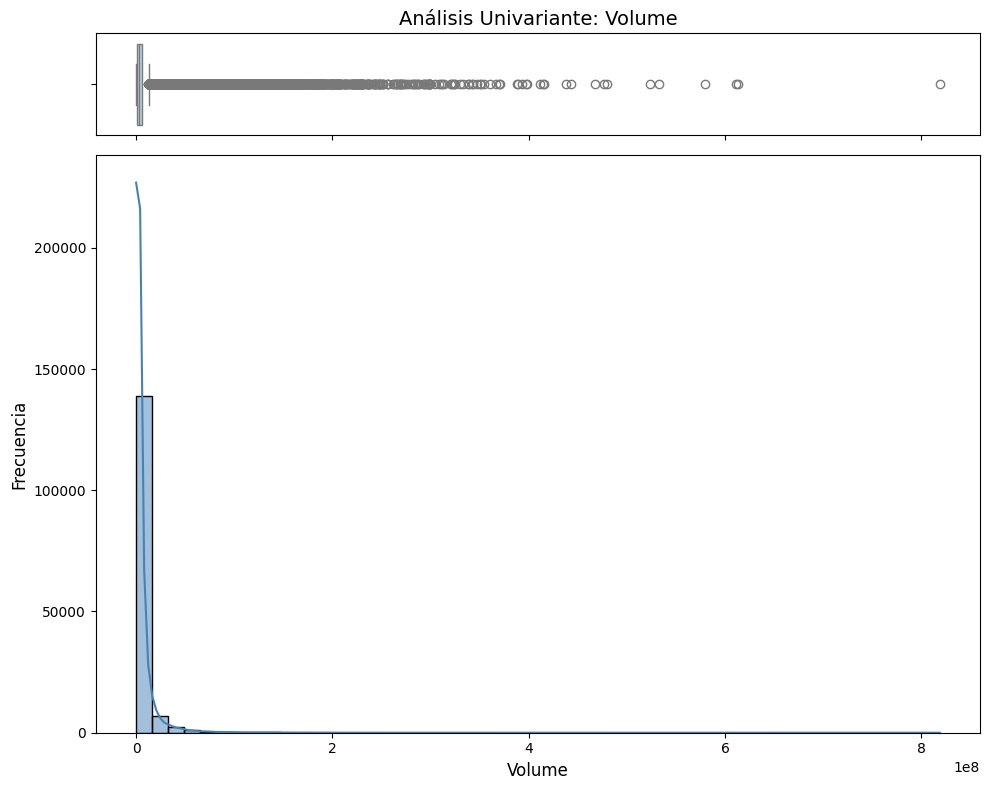

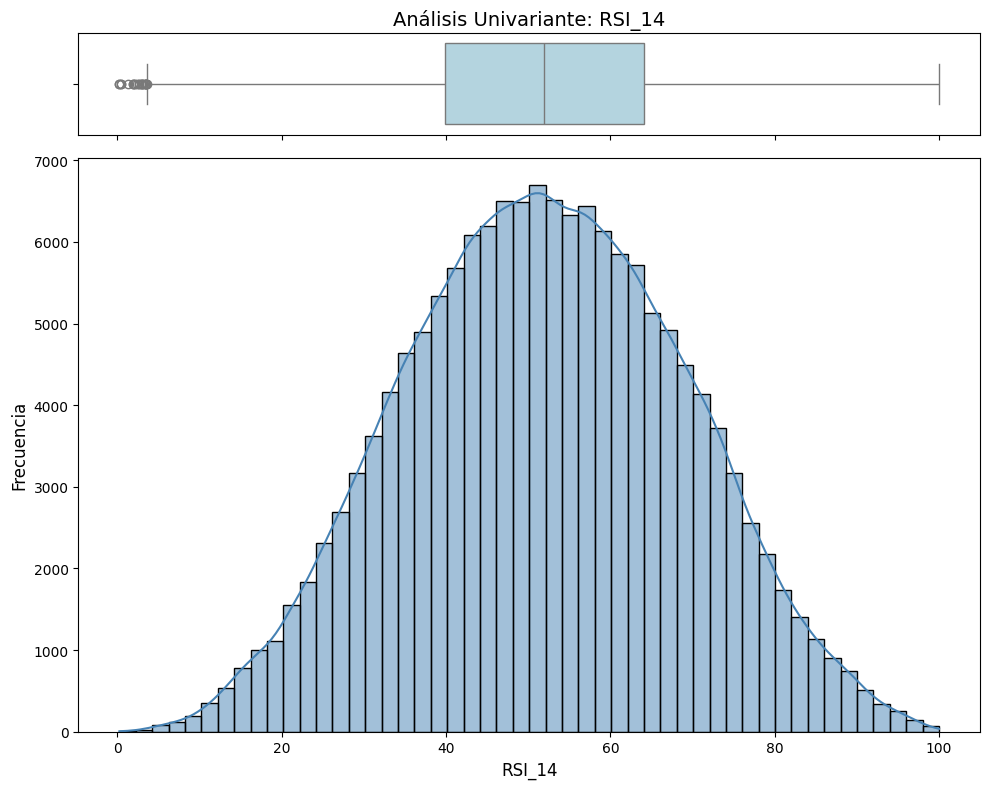

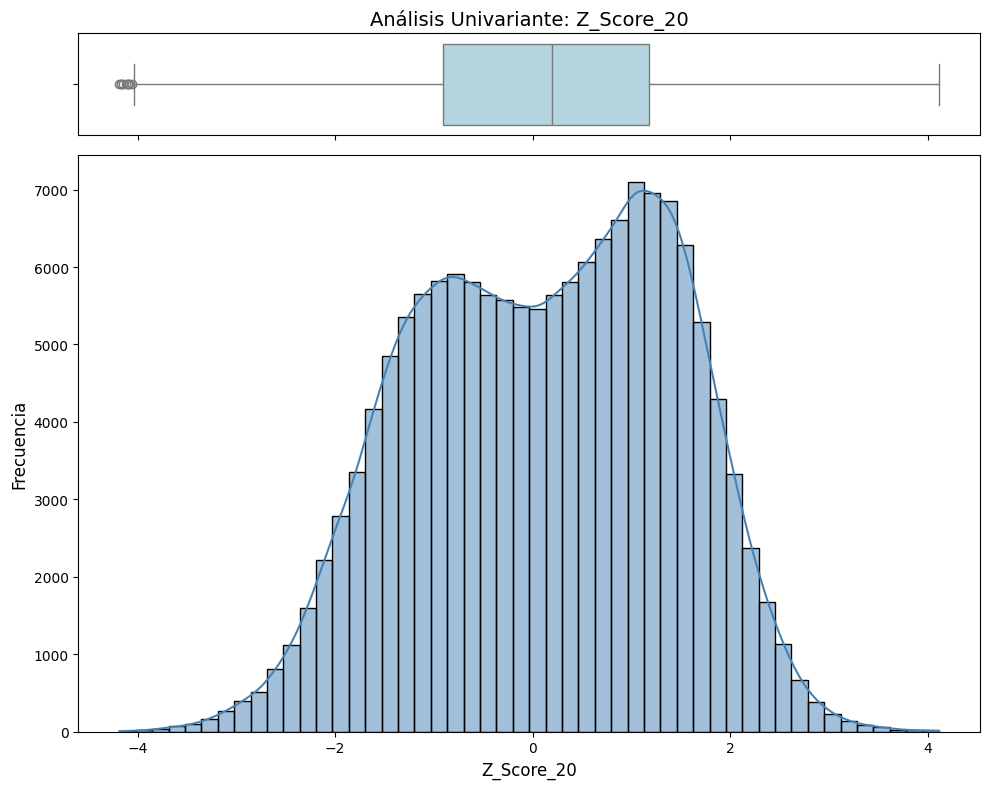

In [24]:
variables_numericas = ['Daily_Return', 'Volume', 'RSI_14', 'Z_Score_20']

for var in variables_numericas:
    fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, 
                                          gridspec_kw={"height_ratios": (.15, .85)})
    
    # Diagrama de caja (Boxplot) arriba para ver outliers
    sns.boxplot(data=final_df, x=var, ax=ax_box, color='lightblue')
    ax_box.set(xlabel='') # Quitamos el label del eje x en el boxplot para que no se repita
    ax_box.set_title(f'Análisis Univariante: {var}', fontsize=14)
    
    # Histograma con curva de densidad (KDE) abajo
    sns.histplot(data=final_df, x=var, kde=True, ax=ax_hist, bins=50, color='steelblue')
    ax_hist.set_ylabel('Frecuencia', fontsize=12)
    ax_hist.set_xlabel(var, fontsize=12)
    
    plt.tight_layout()
    plt.show()

1. Daily_Return (Retorno Diario)
Tiene forma de campana (parece una distribución normal), pero es extremadamente puntiaguda en el centro (alta curtosis) y tiene "colas" muy largas hacia los lados. El boxplot muestra una línea negra sólida de valores atípicos (outliers) a la izquierda y derecha.

Interpretación financiera: La gran mayoría de los días, las acciones no se mueven casi nada (el pico central está en 0.0 o 0%). Sin embargo, las colas largas demuestran que en finanzas los eventos extremos (caídas del 20% o subidas del 20% en un solo día) ocurren con más frecuencia de lo que predeciría una curva normal perfecta.


2. Volume (Volumen de operaciones)
Se ve una asimetría extrema hacia la derecha (right-skewed). Toda la "campana" está aplastada a la izquierda, cerca del cero, y hay una cola larguísima que llega hasta los 800 millones.

Interpretación financiera: La mayoría de las acciones tienen un volumen de transacciones "normal" la mayor parte del tiempo. Pero en días de reportes de ganancias o pánico en el mercado, el volumen explota multiplicándose por 10 o por 100.


3. RSI_14 (Índice de Fuerza Relativa)

Se ve una distribución casi perfectamente simétrica Parece una campana clásica centrada exactamente en el nivel de 50. El boxplot casi no tiene valores atípicos.

Interpretación financiera: El RSI es un oscilador matemático diseñado para estar siempre entre 0 y 100. El gráfico confirma que está haciendo su trabajo: el mercado pasa la mayor parte del tiempo en equilibrio (cerca de 50) y raramente llega a los extremos de sobrecompra (>70) o sobreventa (<30).


4. Lo que se ve (La forma): Es una distribución bimodal. Hay un pico alrededor de -1 y otro pico un poco más alto alrededor de +1, con un "valle" justo en el centro (el 0).

Interpretación financiera: El Z-Score mide qué tan lejos está el precio actual de su media de 20 días. Si los precios se movieran de forma 100% aleatoria alrededor de la media, veríamos un solo pico en el 0. Pero esta forma bimodal demuestra que los mercados tienden a crear tendencias. El precio suele pasar tiempo en tendencias alcistas (el pico en +1, por encima de su media) o en tendencias bajistas (el pico en -1, por debajo de su media), y pasa menos tiempo cruzando exactamente por el medio (el valle en 0)

## Analisis Multivariante

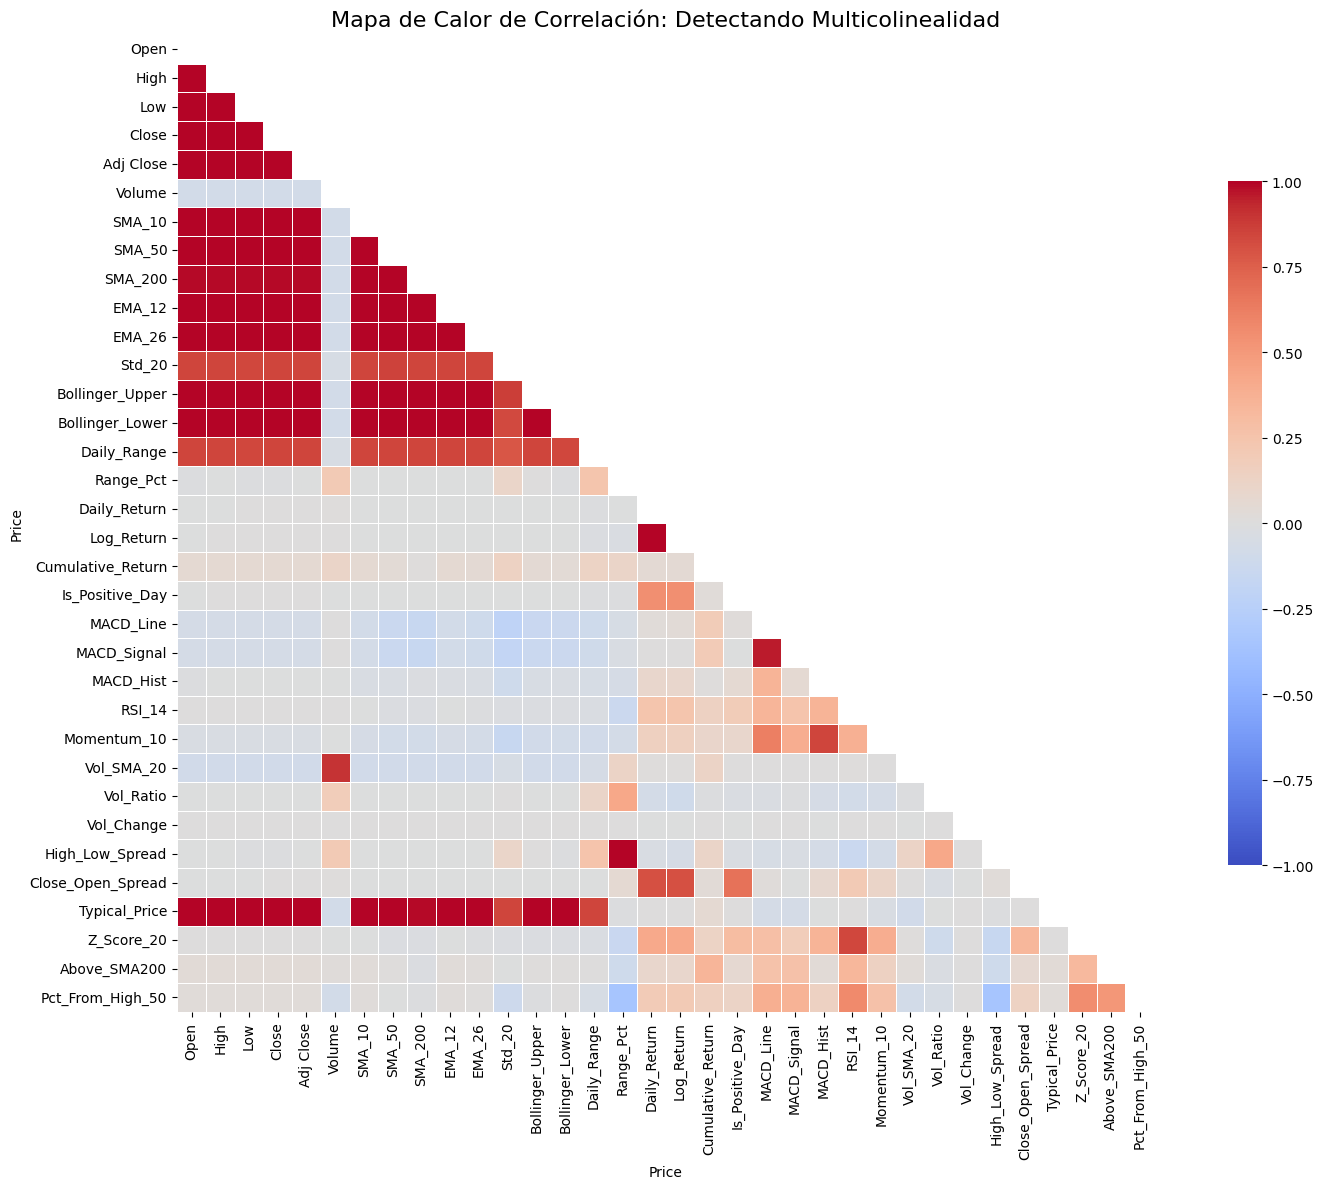

In [25]:
variables_numericas = final_df.select_dtypes(include=[np.number])

# 2. Calculamos la matriz de correlación de Pearson
matriz_corr = variables_numericas.corr()

# 3. Configuramos el tamaño del gráfico
plt.figure(figsize=(16, 12))

# 4. Creamos una máscara para ocultar el triángulo superior (que es un espejo y distrae)
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

# 5. Generamos el Heatmap con Seaborn
sns.heatmap(matriz_corr, 
            mask=mask, 
            cmap='coolwarm', # Rojo para correlación positiva, azul para negativa
            vmax=1, vmin=-1, 
            center=0,
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .7},
            annot=False) # Apagamos los números porque 30 variables harían un desastre visual

plt.title('Mapa de Calor de Correlación: Detectando Multicolinealidad', fontsize=16)
plt.tight_layout()
plt.show()

1. El Cuadrado Rojo Gigante: 
Open, High, Low, Close, Adj Close, SMA_10, SMA_50, SMA_200, EMA_12, EMA_26, Bollinger_Upper, Bollinger_Lower y Typical_Price.
Todas estas variables tienen una correlación cercana a 1.0 (casi perfecta). Básicamente, están gritando exactamente lo mismo: "el precio absoluto de la acción".
Para evitar el overfitting solo elegiremos una o dos para representar el precio general (por ejemplo, quedarte solo con Close y SMA_50).

2. Los Gemelos Idénticos:
Daily_Return y Log_Return. Es un cuadrado rojo oscuro perfecto.
Qué significa: Matemáticamente, el retorno diario normal y el retorno logarítmico son casi idénticos en valores pequeños.
En este caso eliminamos el Log_Return y solo nos quedamos con el Daily_Return por ser más interpretable.

3. Fuga de Datos (Data Leakage) 
La fila/columna de nuestra variable objetivo: Is_Positive_Day. Tiene un color rojo muy fuerte con Daily_Return, Log_Return y Close_Open_Spread.
Qué significa: Un día es "positivo" precisamente cuando el retorno diario es mayor a cero, o cuando el cierre es mayor a la apertura.
El problema para el modelo: Si intentas predecir si un día es positivo, no puedes usar el retorno de ese mismo día para predecirlo, ¡porque eso es hacer trampa! Es como darle al modelo la respuesta del examen antes de que empiece.
Es por ello que eliminamos Daily_Return, Log_Return y Close_Open_Spread del conjunto de variables predictoras (X), porque contienen la respuesta de la variable objetivo (Y).

## Ingeniería de características (feature engineering)

In [26]:
import json

valores_unicos = pd.factorize(final_df['Ticker'])[1]

#Creamos el diccionario automáticamente (ej. {'AAPL': 0, 'MSFT': 1, ...})
diccionario_tickers = {ticker: i for i, ticker in enumerate(valores_unicos)}

# Guardamos este diccionario en un archivo JSON
with open('diccionario_tickers.json', 'w') as archivo:
    json.dump(diccionario_tickers, archivo)

print("¡Diccionario guardado con éxito! Contiene", len(diccionario_tickers), "empresas.")
print(list(diccionario_tickers.items()))

¡Diccionario guardado con éxito! Contiene 498 empresas.
[('MMM', 0), ('AOS', 1), ('ABT', 2), ('ABBV', 3), ('ACN', 4), ('ADBE', 5), ('AMD', 6), ('AES', 7), ('AFL', 8), ('A', 9), ('APD', 10), ('ABNB', 11), ('AKAM', 12), ('ALB', 13), ('ARE', 14), ('ALGN', 15), ('ALLE', 16), ('LNT', 17), ('ALL', 18), ('GOOGL', 19), ('GOOG', 20), ('MO', 21), ('AMZN', 22), ('AMCR', 23), ('AEE', 24), ('AEP', 25), ('AXP', 26), ('AIG', 27), ('AMT', 28), ('AWK', 29), ('AMP', 30), ('AME', 31), ('AMGN', 32), ('APH', 33), ('ADI', 34), ('AON', 35), ('APA', 36), ('APO', 37), ('AAPL', 38), ('AMAT', 39), ('APP', 40), ('APTV', 41), ('ACGL', 42), ('ADM', 43), ('ARES', 44), ('ANET', 45), ('AJG', 46), ('AIZ', 47), ('T', 48), ('ATO', 49), ('ADSK', 50), ('ADP', 51), ('AZO', 52), ('AVB', 53), ('AVY', 54), ('AXON', 55), ('BKR', 56), ('BALL', 57), ('BAC', 58), ('BAX', 59), ('BDX', 60), ('BRK-B', 61), ('BBY', 62), ('TECH', 63), ('BIIB', 64), ('BLK', 65), ('BX', 66), ('XYZ', 67), ('BK', 68), ('BA', 69), ('BKNG', 70), ('BSX', 71),

Creamos un diccionario para de factorizar la variable Ticker y no perdernos, con esto logramos que a la hora de hacer el modelo, entandamos que numero representa cada ticker.

In [27]:
# 1. ORDENAR CRONOLÓGICAMENTE
# Esto garantiza que el pasado quede arriba y el futuro abajo antes de cortar.
final_df = final_df.sort_values(by=['Date', 'Ticker']).reset_index(drop=True)

# 2. CODIFICAR LA VARIABLE CATEGÓRICA (Label Encoding)
final_df['Ticker_Encoded'] = pd.factorize(final_df['Ticker'])[0]

# 3. SELECCIÓN DE CARACTERÍSTICAS (Feature Selection)
# A. Variables que "hacen trampa" revelando el futuro (Fuga de datos / Data Leakage)
fuga_de_datos = ['Daily_Return', 'Log_Return', 'Close_Open_Spread', 'Daily_Range', 'Range_Pct']

# B. Variables de precios absolutos y altamente correlacionadas (Multicolinealidad)
precios_absolutos = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Typical_Price',
                     'SMA_10', 'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26',
                     'Bollinger_Upper', 'Bollinger_Lower']

# C. Variables de identificación que ya no sirven para el modelo
identificadores = ['Date', 'Ticker', 'Cumulative_Return']

# Unimos todas las columnas a descartar
columnas_a_borrar = fuga_de_datos + precios_absolutos + identificadores

X = final_df.drop(columns=columnas_a_borrar + ['Is_Positive_Day'])
y = final_df['Is_Positive_Day']

In [28]:
# 4. DIVISIÓN TRAIN / TEST CRONOLÓGICA (80% Entrenamiento, 20% Prueba)
corte_indice = int(len(final_df) * 0.8)

# Todo lo que está antes del corte (el pasado) es para entrenar
X_train = X.iloc[:corte_indice]
y_train = y.iloc[:corte_indice]

# Todo lo que está después del corte (el futuro) es para probar
X_test = X.iloc[corte_indice:]
y_test = y.iloc[corte_indice:]

print("--- Resumen de la Preparación de Datos ---")
print(f"Total de variables predictoras seleccionadas: {X_train.shape[1]}")
print(f"Filas para Entrenamiento (Train): {X_train.shape[0]}")
print(f"Filas para Prueba (Test): {X_test.shape[0]}")
print("\nVariables finales que verá el modelo:")
print(X.columns.tolist())

--- Resumen de la Preparación de Datos ---
Total de variables predictoras seleccionadas: 15
Filas para Entrenamiento (Train): 120456
Filas para Prueba (Test): 30115

Variables finales que verá el modelo:
['Volume', 'Std_20', 'MACD_Line', 'MACD_Signal', 'MACD_Hist', 'RSI_14', 'Momentum_10', 'Vol_SMA_20', 'Vol_Ratio', 'Vol_Change', 'High_Low_Spread', 'Z_Score_20', 'Above_SMA200', 'Pct_From_High_50', 'Ticker_Encoded']


### Aclaracion importante:
¿Por que no usamos train_test_split?

Porque mezcla los datos al azar. Al ser un proyecto financiero, los datos tienen un orden cronológico estricto. Si los mezclamos, provocamos 'Data Leakage' (fuga de datos del futuro hacia el pasado). Por eso, calculamos manualmente un índice al 80% de la tabla para asegurar que el modelo se entrene exclusivamente con el pasado y se evalúe con el futuro.

# El Combate de Modelos

In [29]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# 1. Inicializar los modelos
# Usamos random_state=42 para que los resultados sean reproducibles
# Usamos n_jobs=-1 para que usen todos los núcleos del procesador 
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
xgb_model = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')

# 2. Entrenar Random Forest
print("🌲 Entrenando Random Forest...")

rf_model.fit(X_train, y_train)


# 3. Entrenar XGBoost
print("\n🚀 Entrenando XGBoost...")

xgb_model.fit(X_train, y_train)


# 4. Hacer predicciones con los datos de Prueba (Test)
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

# 5. Evaluar y comparar resultados

print("🏆 RESULTADOS DEL COMBATE 🏆")


print("\n--- 🌲 RANDOM FOREST ---")
print(classification_report(y_test, rf_pred))

print("\n--- 🚀 XGBOOST ---")
print(classification_report(y_test, xgb_pred))

🌲 Entrenando Random Forest...

🚀 Entrenando XGBoost...
🏆 RESULTADOS DEL COMBATE 🏆

--- 🌲 RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.69      0.75      0.72     14478
           1       0.75      0.68      0.71     15637

    accuracy                           0.72     30115
   macro avg       0.72      0.72      0.72     30115
weighted avg       0.72      0.72      0.72     30115


--- 🚀 XGBOOST ---
              precision    recall  f1-score   support

           0       0.71      0.77      0.74     14478
           1       0.77      0.71      0.74     15637

    accuracy                           0.74     30115
   macro avg       0.74      0.74      0.74     30115
weighted avg       0.74      0.74      0.74     30115



# Optimizacion y Resultados

In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],        # Cantidad de árboles
    'max_depth': [3, 5, 7],            # Profundidad máxima de cada árbol
    'learning_rate': [0.05, 0.1, 0.2]  # Tasa de aprendizaje
}

# 2. Inicializamos el modelo base
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)

# 3. Configuramos el GridSearch (cv=3 significa validación cruzada de 3 pliegues)
grid_search = GridSearchCV(estimator=xgb_base,
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=3,
                           verbose=1) # verbose=1 mostrará una barra de progreso

# 4. Entrenamos el GridSearch con los datos de entrenamiento
grid_search.fit(X_train, y_train)

# 5. Extraemos al campeón absoluto
mejor_xgb = grid_search.best_estimator_

print("\n" + "="*50)
print("🎯 ¡OPTIMIZACIÓN COMPLETADA!")
print("Los mejores hiperparámetros encontrados son:")
print(grid_search.best_params_)
print("="*50)

# 6. Probamos el modelo optimizado con los datos del futuro (Test)
predicciones_optimizadas = mejor_xgb.predict(X_test)

print("\n--- RESULTADOS DEL MODELO OPTIMIZADO ---")
print(classification_report(y_test, predicciones_optimizadas))



Fitting 3 folds for each of 18 candidates, totalling 54 fits

🎯 ¡OPTIMIZACIÓN COMPLETADA!
Los mejores hiperparámetros encontrados son:
{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}

--- RESULTADOS DEL MODELO OPTIMIZADO ---
              precision    recall  f1-score   support

           0       0.71      0.78      0.74     14478
           1       0.77      0.71      0.74     15637

    accuracy                           0.74     30115
   macro avg       0.74      0.74      0.74     30115
weighted avg       0.74      0.74      0.74     30115



In [31]:
import pickle

# 1. Definimos el nombre del archivo donde vivirá tu modelo
nombre_archivo = 'oraculo_financiero2_xgb.pkl'

# 2. Guardamos el modelo optimizado (mejor_xgb) en tu disco duro
with open(nombre_archivo, 'wb') as archivo:
    pickle.dump(mejor_xgb, archivo)

print(f"✅ ¡Éxito! Tu modelo ha sido guardado como '{nombre_archivo}'.")
print("Ya está listo para ser conectado a la web.")

✅ ¡Éxito! Tu modelo ha sido guardado como 'oraculo_financiero2_xgb.pkl'.
Ya está listo para ser conectado a la web.
